In [2]:
from imutils import paths
import random
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2
import numpy as np
from tensorflow.keras.utils import img_to_array

# Visualization

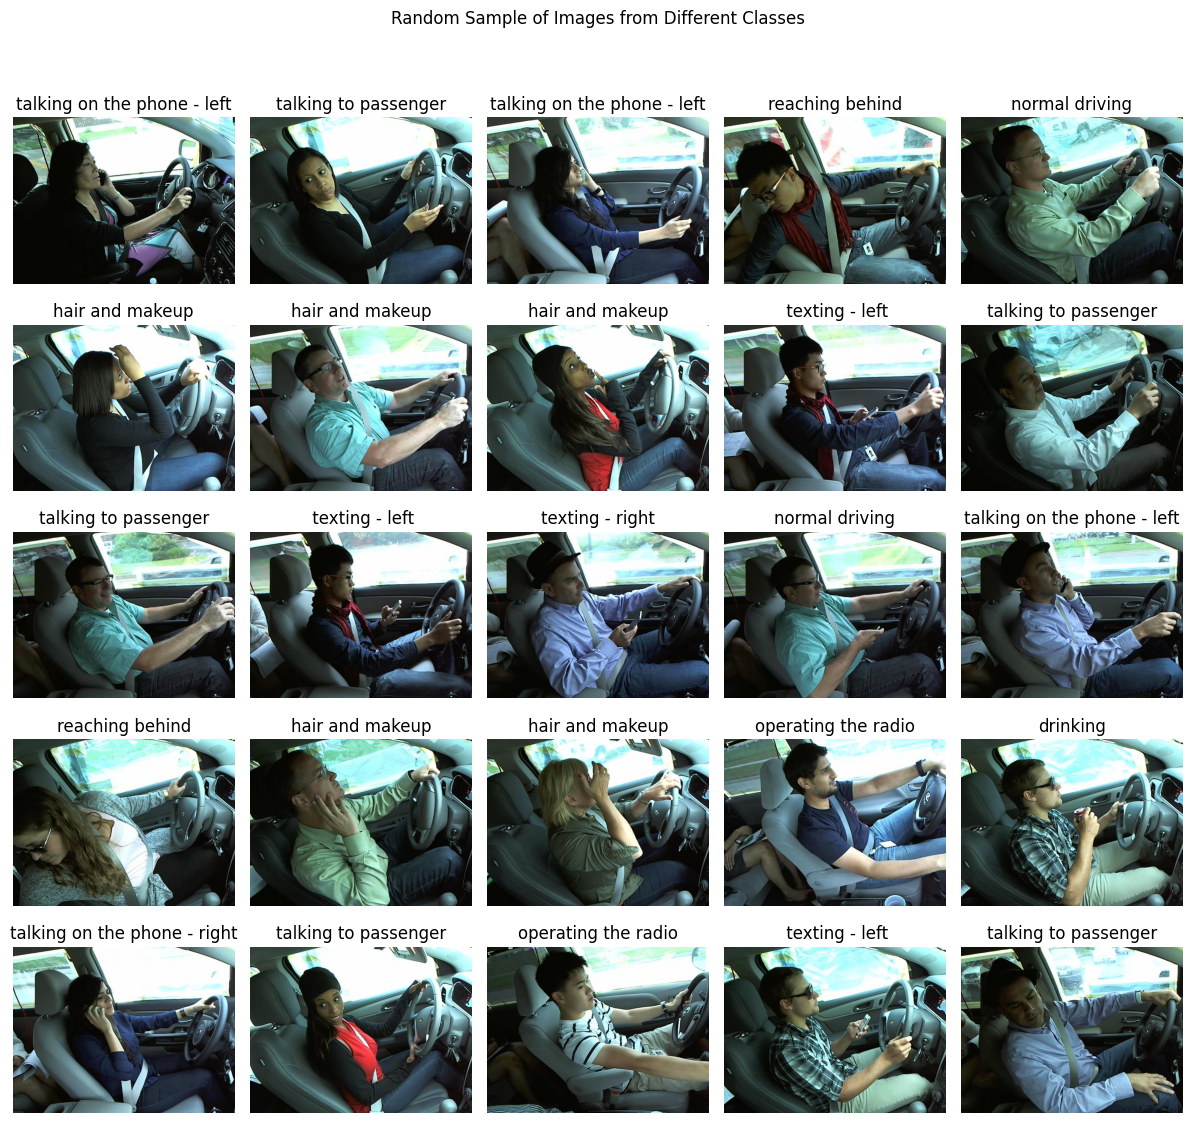

In [3]:
# Get all image paths from the folder
imagePaths = list(paths.list_images("Driver_Distraction_Detection/imgs/train"))
# Function to display a grid of images
classnames = {"c0":"normal driving",
"c1": "texting - right",
"c2": "talking on the phone - right",
"c3":" texting - left",
"c4": "talking on the phone - left",
"c5": "operating the radio",
"c6": "drinking",
"c7": "reaching behind",
"c8": "hair and makeup",
"c9": "talking to passenger"}
def display_images(image_paths, title, cols=5, num_images=25):  # Set cols and add num_images
    random.shuffle(image_paths)  # Shuffle the image paths randomly
    num_images = min(len(image_paths), num_images)  # Limit the number of images to display
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(12, 12))  # Adjust figure size to accommodate more rows
    plt.suptitle(title)

    for i, image_path in enumerate(image_paths[:num_images]):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(image_path)
        plt.imshow(img,cmap = "gray")
        label = classnames.get(os.path.basename(os.path.dirname(image_path)))
        plt.title(label)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Display a random set of images in a 5x5 grid
display_images(imagePaths, title="Random Sample of Images from Different Classes", num_images=25)


# Dataset Preprocessing

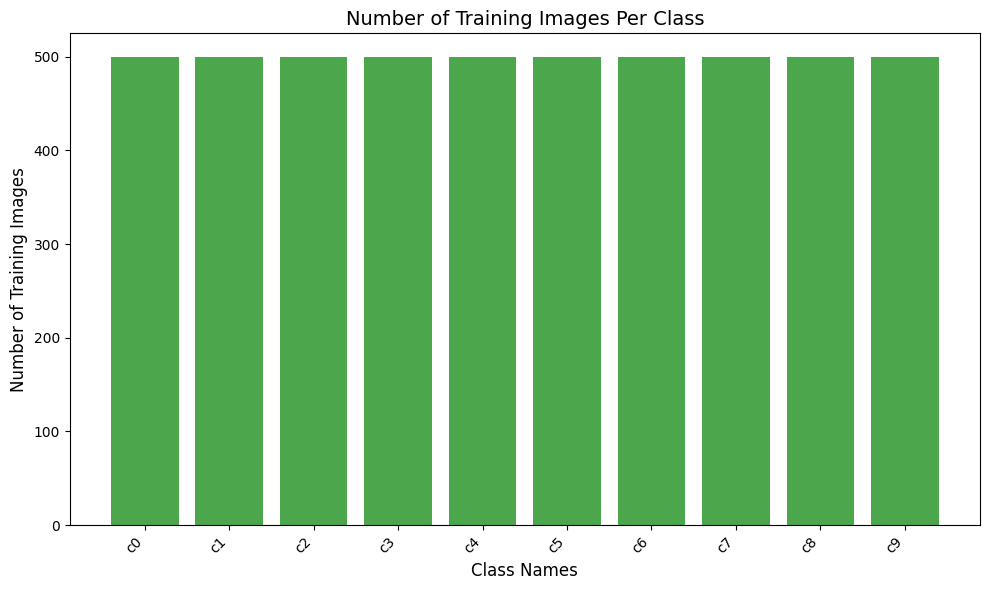

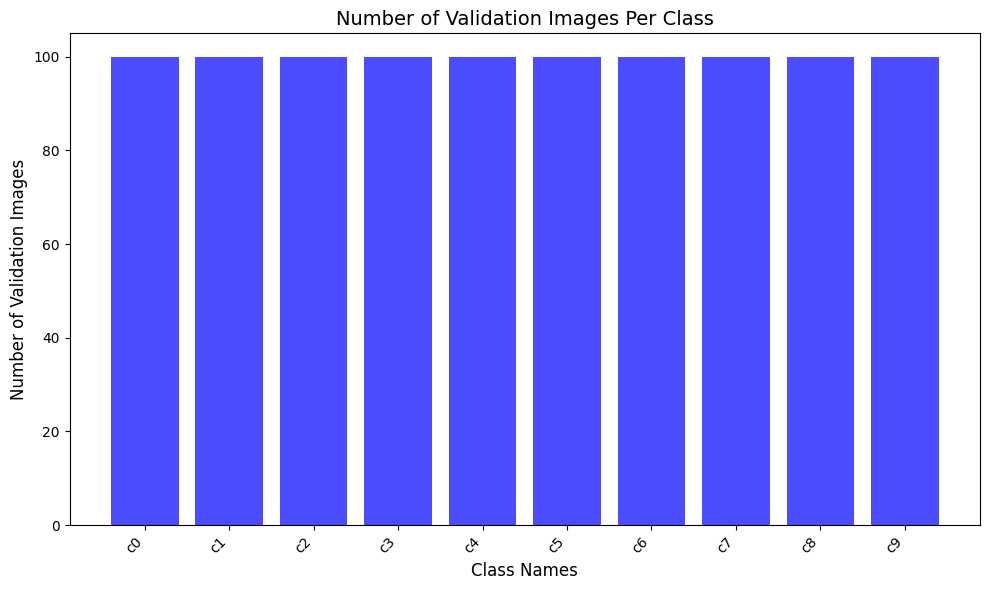

In [4]:
import os
import random
import matplotlib.pyplot as plt

# Folder containing all classes
data_folder = "Driver_Distraction_Detection/imgs/train"

# Number of images needed for train and validation
train_count = 500
val_count = 100

# Dictionary to store train and validation paths
train_paths = {cls: [] for cls in os.listdir(data_folder)}
val_paths = {cls: [] for cls in os.listdir(data_folder)}

# Iterate through each class folder
for cls in train_paths.keys():
    class_folder = os.path.join(data_folder, cls)
    if os.path.isdir(class_folder):
        # Get all image paths in the class folder
        images = [os.path.join(class_folder, img) for img in os.listdir(class_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
        # Shuffle the images to randomize the selection
        random.shuffle(images)
        # Split into train and validation
        train_paths[cls] = images[:train_count]
        val_paths[cls] = images[train_count:train_count + val_count]

# Count images per class for train and validation
train_counts = {cls: len(paths) for cls, paths in train_paths.items()}
val_counts = {cls: len(paths) for cls, paths in val_paths.items()}

# Visualization: Bar plot for training image counts
plt.figure(figsize=(10, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='green', alpha=0.7)
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Training Images", fontsize=12)
plt.title("Number of Training Images Per Class", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

# Visualization: Bar plot for validation image counts
plt.figure(figsize=(10, 6))
plt.bar(val_counts.keys(), val_counts.values(), color='blue', alpha=0.7)
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Validation Images", fontsize=12)
plt.title("Number of Validation Images Per Class", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()


In [5]:
import cv2
import os
import numpy as np
class SimpleDatasetLoader:
	def __init__(self, preprocessors=None):
		# store the image preprocessor
		self.preprocessors = preprocessors

		# if the preprocessors are None, initialize them as an
		# empty list
		if self.preprocessors is None:
			self.preprocessors = []

	def load(self, imagePaths, verbose=-1):
		# initialize the list of features and labels
		data = []
		labels = []

		# loop over the input images
		for (i, imagePath) in enumerate(imagePaths):
			# load the image and extract the class label assuming
			# that our path has the following format:
			# /path/to/dataset/{class}/{image}.jpg
			image = cv2.imread(imagePath)
			label = imagePath.split(os.path.sep)[-2]

			# check to see if our preprocessors are not None
			if self.preprocessors is not None:
				# loop over the preprocessors and apply each to
				# the image
				for p in self.preprocessors:
					image = p.preprocess(image)

			# treat our processed image as a "feature vector"
			# by updating the data list followed by the labels
			data.append(image)
			labels.append(label)

			# show an update every `verbose` images
			if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
				print("[INFO] processed {}/{}".format(i + 1,
					len(imagePaths)))

		# return a tuple of the data and labels
		return (np.array(data), np.array(labels))

In [6]:
import cv2
class SimplePreprocessor:
	def __init__(self, width, height, inter=cv2.INTER_AREA):
		# store the target image width, height, and interpolation
		# method used when resizing
		self.width = width
		self.height = height
		self.inter = inter

	def preprocess(self, image):
		# resize the image to a fixed size, ignoring the aspect
		# ratio
		return cv2.resize(image, (self.width, self.height),
			interpolation=self.inter)

In [7]:
from tensorflow.keras.preprocessing.image import img_to_array
class ImageToArrayPreprocessor:
	def __init__(self, dataFormat=None):
		# store the image data format
		self.dataFormat = dataFormat

	def preprocess(self, image):
		# apply the Keras utility function that correctly rearranges
		# the dimensions of the image
		return img_to_array(image, data_format=self.dataFormat)

In [8]:
# initialize the image preprocessors
sp = SimplePreprocessor(128,128)
iap = ImageToArrayPreprocessor()

In [9]:
# Combine all training image paths into a single list
all_train_paths = [path for paths in train_paths.values() for path in paths]

# Combine all validation image paths into a single list (optional)
all_val_paths = [path for paths in val_paths.values() for path in paths]

# Output the size of the lists
print(f"Total training images: {len(all_train_paths)}")
print(f"Total validation images: {len(all_val_paths)}")


Total training images: 5000
Total validation images: 1000


The execution may take some time to complete due to the large number of images, exceeding 2700 in this case

In [10]:
# load the dataset
sdl = SimpleDatasetLoader(preprocessors=[sp,iap])
(train_data, train_labels) = sdl.load(all_train_paths, verbose=1000)

[INFO] processed 1000/5000
[INFO] processed 2000/5000
[INFO] processed 3000/5000
[INFO] processed 4000/5000
[INFO] processed 5000/5000


In [11]:
# load the dataset
sdl = SimpleDatasetLoader(preprocessors=[sp,iap])
(val_data, val_labels) = sdl.load(all_val_paths, verbose=500)

[INFO] processed 500/1000
[INFO] processed 1000/1000


# Image Normalization

In [12]:
# Data Normalization for all train and validatoin all image
train_scaled_data = train_data.astype('float32')/255
val_scaled_data = val_data.astype('float32')/255

In [13]:
# Since the dataloader function takes some time to complete, we can store it in the npy file format for tim taken and don't execute again dataloader function
np.save("Driver_Distraction_Detection/train_scaled_data.npy",train_scaled_data)
np.save("Driver_Distraction_Detection/train_labels.npy",train_labels)
np.save("Driver_Distraction_Detection/val_scaled_data.npy",val_scaled_data)
np.save("Driver_Distraction_Detection/val_labels.npy",val_labels)

In [14]:
# load the saved in npy format
import numpy as np
train_scaled_data = np.load("Driver_Distraction_Detection/train_scaled_data.npy")
train_labels = np.load("Driver_Distraction_Detection/train_labels.npy")
val_scaled_data = np.load("Driver_Distraction_Detection/val_scaled_data.npy")
val_labels = np.load("Driver_Distraction_Detection/val_labels.npy")

In [15]:
print('train_scaled_data',train_scaled_data.shape,'val_scaled_data',val_scaled_data.shape,'train_labels',train_labels.shape,'val_labels',val_labels.shape)

train_scaled_data (5000, 128, 128, 3) val_scaled_data (1000, 128, 128, 3) train_labels (5000,) val_labels (1000,)


In [16]:
import pandas as pd
train_val_data = {'total data':[len(train_scaled_data),len(val_scaled_data),len(train_labels),len(val_labels)]}
pd.DataFrame.from_dict(train_val_data, orient='index',columns=["train_scaled_data","train_labels","val_scaled_data","val_labels"])

,train_scaled_data,train_labels,val_scaled_data,val_labels
total data,5000,1000,5000,1000


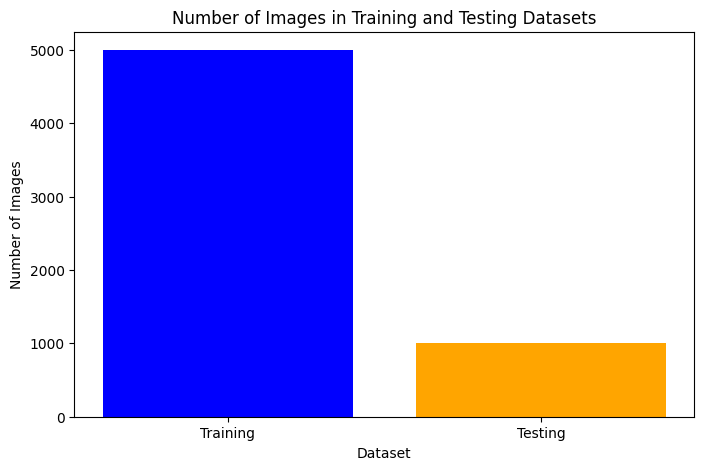

In [17]:
# Calculate the number of images for training and testing
import matplotlib.pyplot as plt
num_train_images = len(train_scaled_data)
num_test_images = len(val_scaled_data)
# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(['Training', 'Testing'], [num_train_images, num_test_images], color=['blue', 'orange'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Number of Images in Training and Testing Datasets')
plt.show()


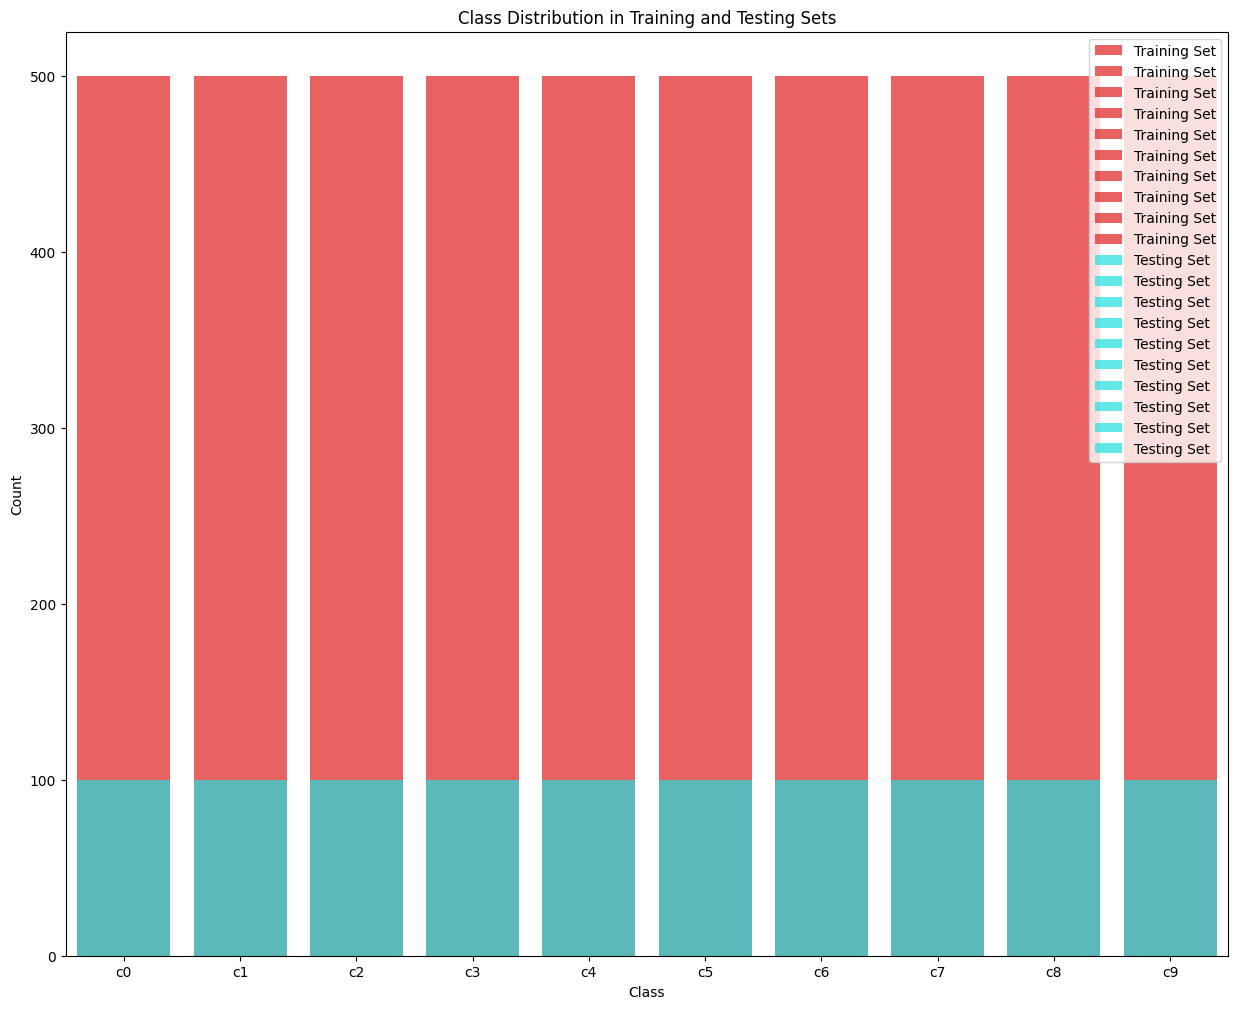

In [18]:
# Convert y_train and y_test back to DataFrames
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
train_data = pd.DataFrame({'Class': train_labels})
test_data = pd.DataFrame({'Class': val_labels})

train_color = ["red"]
test_color = ["cyan"]

# Create a bar plot to visualize the class distribution in the training and testing sets
plt.figure(figsize=(15, 12))
sns.countplot(x='Class', data=train_data, palette=train_color, alpha=0.7, label='Training Set',legend=False)
sns.countplot(x='Class', data=test_data, palette=test_color, alpha=0.7, label='Testing Set',legend=False)
plt.title('Class Distribution in Training and Testing Sets')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend()
plt.show()


# Apply to_categorical for Target Output

LabelBinarizer converts integer class labels into binary class matrices suitable for deep learning models, ensuring compatibility and enabling the use of categorical cross-entropy loss.
One-hot encoding facilitates clearer interpretation of model predictions, simplifies loss calculation, and enables the computation of evaluation metrics in classification tasks

In [19]:
# convert the labels from integers to vectors
from sklearn.preprocessing import LabelBinarizer
y_train_label = LabelBinarizer().fit_transform(train_labels)
y_test_label = LabelBinarizer().fit_transform(val_labels)


# Training using ResNet-50 Algorithm

In [ ]:

# import os
# import h5py
# import math
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras.models import Model, load_model
# from tensorflow.keras import layers
# from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
# from tensorflow.keras.preprocessing import image
# from tensorflow.keras.applications.imagenet_utils import preprocess_input
# from IPython.display import SVG
# from tensorflow.keras.utils import plot_model
# from tensorflow.keras.initializers import glorot_uniform
# import scipy.misc
# import matplotlib.pyplot as plt
# from matplotlib.pyplot import imshow
# from tensorflow.keras.optimizers import Adam
# %matplotlib inline
# import tensorflow.keras.backend as K
# # Image dataset has channels as its last dimensions
# K.set_image_data_format('channels_last')
# TF_USE_LEGACY_KERAS=True

In [ ]:
# def identity_block(X, f, filters, stage, block):

#   '''
#   Implementation of identity block described above

#   Arguments:
#   X -       input tensor to the block of shape (m, n_H_prev, n_W_prev, n_C_prev)
#   f -       defines shpae of filter in the middle layer of the main path
#   filters - list of integers, defining the number of filters in each layer of the main path
#   stage -   defines the block position in the network
#   block -   used for naming convention

#   Returns:
#   X - output is a tensor of shape (n_H, n_W, n_C) which matches (m, n_H_prev, n_W_prev, n_C_prev)
#   '''

#   # defining base name for block
#   conv_base_name = 'res' + str(stage) + block + '_'
#   bn_base_name = 'bn' + str(stage) + block + '_'

#   # retrieve number of filters in each layer of main path
#   # NOTE: f3 must be equal to n_C. That way dimensions of the third component will match the dimension of original input to identity block
#   f1, f2, f3 = filters

#   # Batch normalization must be performed on the 'channels' axis for input. It is 3, for our case
#   bn_axis = 3

#   # save input for "addition" to last layer output; step in skip-connection
#   X_skip_connection = X

#   # ----------------------------------------------------------------------
#   # Building layers/component of identity block using Keras functional API

#   # First component/layer of main path
#   X = Conv2D(filters= f1, kernel_size = (1,1), strides = (1,1), padding='valid', name=conv_base_name+'first_component', kernel_initializer = glorot_uniform(seed=0))(X)
#   X = BatchNormalization(axis=bn_axis, name=bn_base_name+'first_component')(X)
#   X = Activation('relu')(X)

#   # Second component/layer of main path
#   X = Conv2D(filters= f2, kernel_size = (f,f), strides = (1,1), padding='same', name=conv_base_name+'second_component', kernel_initializer = glorot_uniform(seed=0))(X)
#   X = BatchNormalization(axis=bn_axis, name=bn_base_name+'second_component')(X)
#   X = Activation('relu')(X)

#   # Third component/layer of main path
#   X = Conv2D(filters= f3, kernel_size = (1,1), strides = (1,1), padding='valid', name=conv_base_name+'third_component', kernel_initializer = glorot_uniform(seed=0))(X)
#   X = BatchNormalization(axis=bn_axis, name=bn_base_name+'third_component')(X)

#   # "Addition step" - skip-connection value merges with main path
#   # NOTE: both values have same dimensions at this point, so no operation is required to match dimensions
#   X = Add()([X, X_skip_connection])
#   X = Activation('relu')(X)

#   return X

In [ ]:
# def convolutional_block(X, f, filters, stage, block, s = 2):
#     """
#     Implementation of the convolutional block as defined in above figure

#     Arguments:
#     X -       input tensor to the block of shape (m, n_H_prev, n_W_prev, n_C_prev)
#     f -       defines shape of filter in the middle layer of the main path
#     filters - list of integers, defining the number of filters in each layer of the main path
#     stage -   defines the block position in the network
#     block -   used for naming convention
#     s -       specifies the stride to be used

#     Returns:
#     X -- output of the convolutional block, tensor of shape (n_H, n_W, n_C)
#     """

#     # defining base name for block
#     conv_base_name = 'res' + str(stage) + block + '_'
#     bn_base_name = 'bn' + str(stage) + block + '_'

#     # retrieve number of filters in each layer of main path
#     f1, f2, f3 = filters

#     # Batch normalization must be performed on the 'channels' axis for input. It is 3, for our case
#     bn_axis = 3

#     # save input for "addition" to last layer output; step in skip-connection
#     X_skip_connection = X

#     ##### MAIN PATH #####
#     # First component of main path
#     X = Conv2D(f1, (1, 1), strides = (s,s), padding = 'valid', name = conv_base_name + 'first_component', kernel_initializer = glorot_uniform(seed=0))(X)
#     X = BatchNormalization(axis = bn_axis, name = bn_base_name + 'first_component')(X)
#     X = Activation('relu')(X)

#     # Second component of main path
#     X = Conv2D(f2,  kernel_size = (f, f), strides = (1,1), padding = 'same', name = conv_base_name + 'second_component', kernel_initializer = glorot_uniform(seed=0))(X)
#     X = BatchNormalization(axis = bn_axis, name = bn_base_name + 'second_component')(X)
#     X = Activation('relu')(X)

#     # Third component of main path
#     X = Conv2D(f3, kernel_size = (1, 1), strides = (1,1), padding = 'valid', name = conv_base_name + 'third_component', kernel_initializer = glorot_uniform(seed=0))(X)
#     X = BatchNormalization(axis = bn_axis, name = bn_base_name + 'third_component')(X)

#     ##### Convolve skip-connection value to match its dimensions to third layer output's dimensions ####
#     X_skip_connection = Conv2D(f3, (1, 1), strides = (s,s), padding = 'valid', name = conv_base_name + 'merge', kernel_initializer = glorot_uniform(seed=0))(X_skip_connection)
#     X_skip_connection = BatchNormalization(axis = 3, name = bn_base_name + 'merge')(X_skip_connection)

#     # "Addition step"
#     # NOTE: both values have same dimensions at this point
#     X = Add()([X, X_skip_connection])
#     X = Activation('relu')(X)

#     return X

In [ ]:
# def ResNet50(input_shape,classes ):
#     """
#     Arguments:
#     input_shape - shape of the images of the dataset
#     classes - number of classes

#     Returns:
#     model - a Model() instance in Keras

#     """

#     # plug in input_shape to define the input tensor
#     X_input = Input(input_shape)

#     # Zero-Padding : pads the input with a pad of (3,3)
#     X = ZeroPadding2D((3, 3))(X_input)

#     # Stage 1
#     X = Conv2D(64, (7, 7), strides = (2, 2), name = 'conv_1', kernel_initializer = glorot_uniform(seed=0))(X)
#     X = BatchNormalization(axis = 3, name = 'bn_1')(X)
#     X = Activation('relu')(X)
#     X = MaxPooling2D((3, 3), strides=(2, 2))(X)

#     # NOTE: dimensions of filters that are passed to identity block are such that final layer output
#     # in identity block mathces the original input to the block
#     # blocks in each stage are alphabetically sequenced

#     # Stage 2
#     X = convolutional_block(X, f = 3, filters = [64, 64, 256], stage = 2, block='a', s = 1)
#     X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
#     X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

#     # Stage 3
#     X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
#     X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
#     X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
#     X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

#     # Stage 4
#     X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
#     X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
#     X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
#     X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
#     X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
#     X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

#     # Stage 5
#     X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
#     X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
#     X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

#     # Average Pooling
#     X = AveragePooling2D((2, 2), name='avg_pool')(X)

#     # output layer
#     X = Flatten()(X)
#     X = Dense(512, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
#     X = Dense(256, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
#     X = Dense(128, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
#     X = Dense(64, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
#     X = Dense(classes, activation='softmax', name='fc' + str(classes), kernel_initializer=glorot_uniform(seed=0))(X)
#     # Create model
#     model = Model(inputs = X_input, outputs = X, name='ResNet50')

#     return model

In [ ]:

# model = ResNet50(input_shape = (128,128, 3), classes = 10)
# model.compile(optimizer=Adam(learning_rate = 0.001), loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 134, 134, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_1 (Conv2D)           │ (None, 64, 64, 64)     │          9,472 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_1 (BatchNormalization) │ (None, 64, 64, 64)     │            256 │ conv_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 64, 64, 64)     │              0 │ bn_1[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 31, 31, 64)     │              0 │ activation[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res2a_first_component     │ (None, 31, 31, 64)     │          4,160 │ max_pooling2d[0][0]    │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn2a_first_component      │ (None, 31, 31, 64)     │            256 │ res2a_first_component… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 31, 31, 64)     │              0 │ bn2a_first_component[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res2a_second_component    │ (None, 31, 31, 64)     │         36,928 │ activation_1[0][0]     │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn2a_second_component     │ (None, 31, 31, 64)     │            256 │ res2a_second_componen… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 31, 31, 64)     │              0 │ bn2a_second_component… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res2a_third_component     │ (None, 31, 31, 256)    │         16,640 │ activation_2[0][0]     │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ res2a_merge (Conv2D)      │ (None, 31, 31, 256)    │         16,640 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn2a_third_component      │ (None, 31, 31, 256)    │          1,024 │ res2a_third_component… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn2a_merge           

 Total params: 27,955,658 (106.64 MB)

 Trainable params: 27,902,538 (106.44 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# from tensorflow.keras.callbacks import ModelCheckpoint
# import pickle

# # Define the checkpoint callback
# checkpoint = ModelCheckpoint(
#     filepath='Driver_Distraction_Detection/restnet_50.weights.h5',  # Filepath to save the best weights
#     monitor='val_accuracy',                     # Metric to monitor
#     save_best_only=True,                    # Save only the best weights
#     save_weights_only=True,                 # Save only weights, not the full model
#     mode='max',                             # 'min' for validation loss
#     verbose=1                               # Print messages when saving
# )

# # Train the model with the checkpoint callback
# history = model.fit(
#     train_scaled_data,
#     y_train_label,
#     batch_size=16,
#     epochs=10,                                # You can set more epochs
#     validation_data=(val_scaled_data, y_test_label),
#     callbacks=[checkpoint]                    # Add the callback here
# )


# # Save the training history separately
# with open('Driver_Distraction_Detection/resnet_50.pkl', 'wb') as file:
#     pickle.dump(history.history, file)


# print("resnet-50 classification model trained, and best weights saved!")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.1006 - loss: 3.0662
Epoch 1: val_accuracy improved from -inf to 0.14300, saving model to /content/gdrive/MyDrive/Driver_Distraction_Detection/restnet_50.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 121s 185ms/step - accuracy: 0.1006 - loss: 3.0645 - val_accuracy: 0.1430 - val_loss: 2.4379
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2509 - loss: 1.9238
Epoch 2: val_accuracy improved from 0.14300 to 0.35800, saving model to /content/gdrive/MyDrive/Driver_Distraction_Detection/restnet_50.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 128ms/step - accuracy: 0.2511 - loss: 1.9231 - val_accuracy: 0.3580 - val_loss: 2.2118
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4876 - loss: 1.3126
Epoch 3: val_accuracy improved from 0.35800 to 0.48500, saving model to /content/gdrive/MyDrive/Driver_Distraction_Detection/restnet_50.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.4

In [35]:
from vit_keras import vit
import sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import numpy as np
import pickle

train_dir = "Driver_Distraction_Detection/imgs/train"

datagen = ImageDataGenerator(
    preprocessing_function=vit.preprocess_inputs,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

vit_base = vit.vit_b16(
    image_size=224, activation='softmax', pretrained=True, 
    include_top=False, pretrained_top=False
)

vit_base.trainable = False 

model = tf.keras.Sequential([
    vit_base,
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=tfa.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

vit_base.trainable = True
for layer in vit_base.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=tfa.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

model.save_weights('vit_distraction_weights.weights.h5')

with open('train_history.pkl', 'wb') as f:
    pickle.dump({'phase1': history_phase1.history, 'phase2': history_phase2.history}, f)

predictions = model.predict(val_generator, verbose=1)
y_true = val_generator.classes
y_pred = np.argmax(predictions, axis=1)
classNames = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=classNames))

Found 17943 images belonging to 10 classes.
Found 4481 images belonging to 10 classes.
Epoch 1/5
2243/2243 [==============================] - 301s 131ms/step - loss: 1.2482 - accuracy: 0.5795 - val_loss: 0.7036 - val_accuracy: 0.7746
Epoch 2/5
2243/2243 [==============================] - 288s 128ms/step - loss: 0.9009 - accuracy: 0.6938 - val_loss: 0.6257 - val_accuracy: 0.7971
Epoch 3/5
2243/2243 [==============================] - 312s 139ms/step - loss: 0.8594 - accuracy: 0.7148 - val_loss: 0.5847 - val_accuracy: 0.8103
Epoch 4/5
2243/2243 [==============================] - 306s 137ms/step - loss: 0.8578 - accuracy: 0.7157 - val_loss: 0.5691 - val_accuracy: 0.8183
Epoch 5/5
2243/2243 [==============================] - 304s 135ms/step - loss: 0.8546 - accuracy: 0.7189 - val_loss: 0.5983 - val_accuracy: 0.8056
Epoch 1/15
2243/2243 [==============================] - 360s 157ms/step - loss: 0.6495 - accuracy: 0.7915 - val_loss: 0.3440 - val_accuracy: 0.8989
Epoch 2/15
2243/2243 [========

In [66]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Lấy dữ liệu dự đoán
y_true = val_generator.classes
y_pred = np.argmax(predictions, axis=1)
classNames = list(val_generator.class_indices.keys())

# 2. Tạo Classification Report dạng Dictionary
report_dict = classification_report(y_true, y_pred, target_names=classNames, output_dict=True)

# 3. Chuyển thành Pandas DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# 4. Tính toán Cột Accuracy cho từng Class từ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
total_samples = np.sum(cm)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = total_samples - (fp + fn + tp)

class_accuracies = (tp + tn) / total_samples

# 5. Thêm cột "Accuracy" vào DataFrame (vị trí index số 3 là ngay sau F1-score)
accuracy_col = list(class_accuracies) + [np.nan] * (len(report_df) - len(classNames))
report_df.insert(3, 'accuracy_per_class', accuracy_col)

# 6. Làm tròn 4 chữ số thập phân
report_df = report_df.round(4)

# 7. Đổi tên cột cho đẹp
report_df.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1-Score',
    'accuracy_per_class': 'Class Accuracy',
    'support': 'Support (Mẫu)'
}, inplace=True)

# 8. In ra màn hình bằng hàm print cơ bản
print("CLASSIFICATION REPORT")
print(report_df.to_string(na_rep='-')) # na_rep='-' để in các ô NaN (trống) thành dấu gạch ngang cho đẹp

# (Tùy chọn) Xuất ra Excel
# report_df.to_excel("Classification_Report_Detail.xlsx")

CLASSIFICATION REPORT
              Precision  Recall  F1-Score  Class Accuracy  Support (Mẫu)
c0               0.9813  0.9497    0.9652          0.9924       497.0000
c1               0.9869  0.9978    0.9923          0.9984       453.0000
c2               0.9809  1.0000    0.9904          0.9980       463.0000
c3               0.9894  0.9936    0.9915          0.9982       469.0000
c4               0.9872  0.9957    0.9914          0.9982       465.0000
c5               0.9935  0.9892    0.9913          0.9982       462.0000
c6               0.9809  0.9935    0.9872          0.9973       465.0000
c7               1.0000  0.9975    0.9987          0.9998       400.0000
c8               0.9832  0.9215    0.9514          0.9920       382.0000
c9               0.9412  0.9788    0.9596          0.9922       425.0000
accuracy         0.9824  0.9824    0.9824               -         0.9824
macro avg        0.9824  0.9817    0.9819               -      4481.0000
weighted avg     0.9825  0.98

# Confusion matrix

Confusion Matrix:


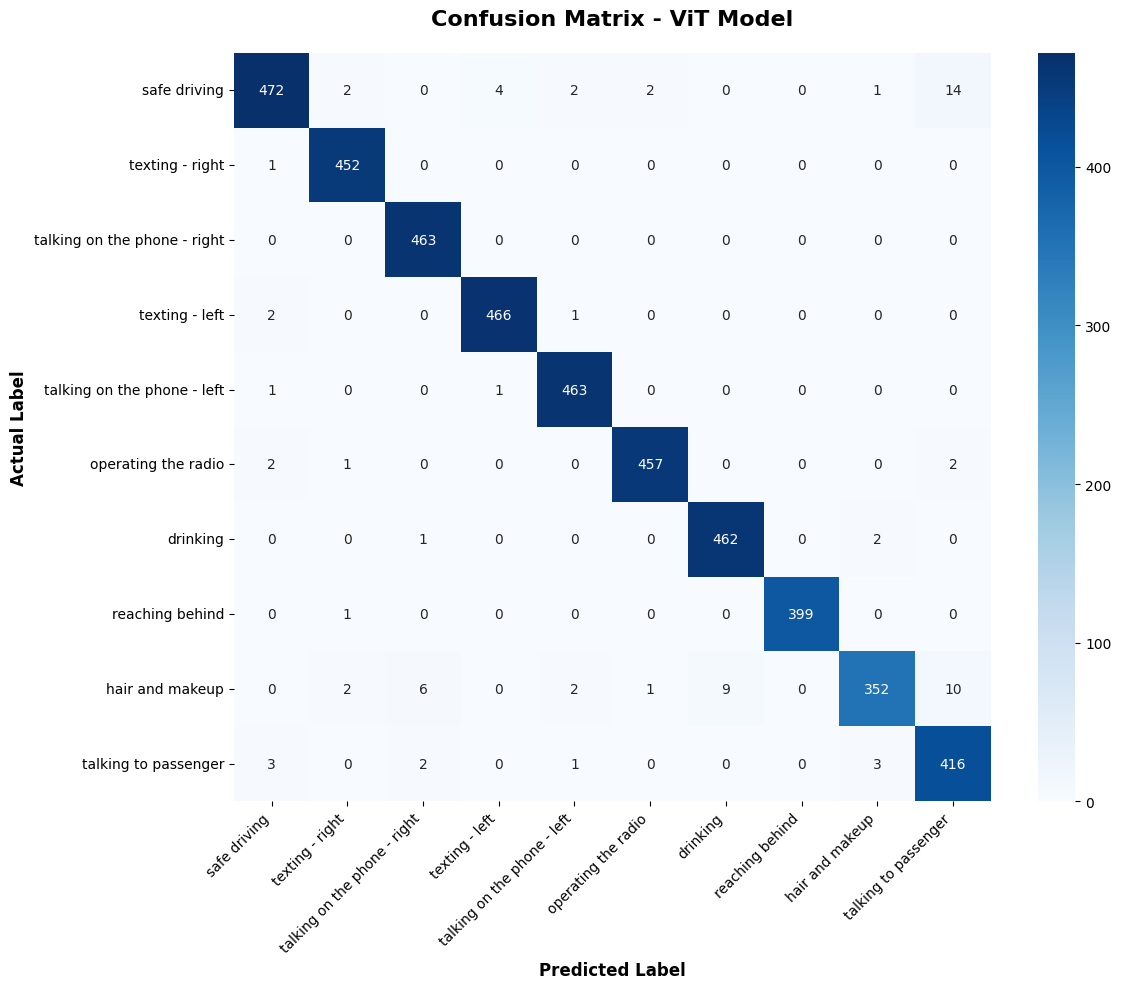

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Lấy dữ liệu thực tế và dự đoán (từ val_generator ở các bước trước)
y_true = val_generator.classes
y_pred = np.argmax(predictions, axis=1)

classNames = [
    "safe driving",
    "texting - right",
    "talking on the phone - right",
    "texting - left",
    "talking on the phone - left",
    "operating the radio",
    "drinking",
    "reaching behind",
    "hair and makeup",
    "talking to passenger"
]

# 2. Tính toán ma trận nhầm lẫn
CM = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")

# 3. Cấu hình biểu đồ
plt.figure(figsize=(12, 10)) # Tăng kích thước để chứa vừa text dài
sns.heatmap(CM, annot=True, fmt="d", cmap="Blues", 
            xticklabels=classNames, yticklabels=classNames)

# Đặt đúng nhãn trục chuẩn của Sklearn
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("Actual Label", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix - ViT Model", fontsize=16, fontweight='bold', pad=20)

# Xoay text trục X nghiêng 45 độ và căn phải để chữ không bị đè lên nhau
plt.xticks(rotation=45, ha='right')

# Tự động căn lề để không bị mất chữ ở các cạnh
plt.tight_layout() 
plt.show()

# Training and validation loss

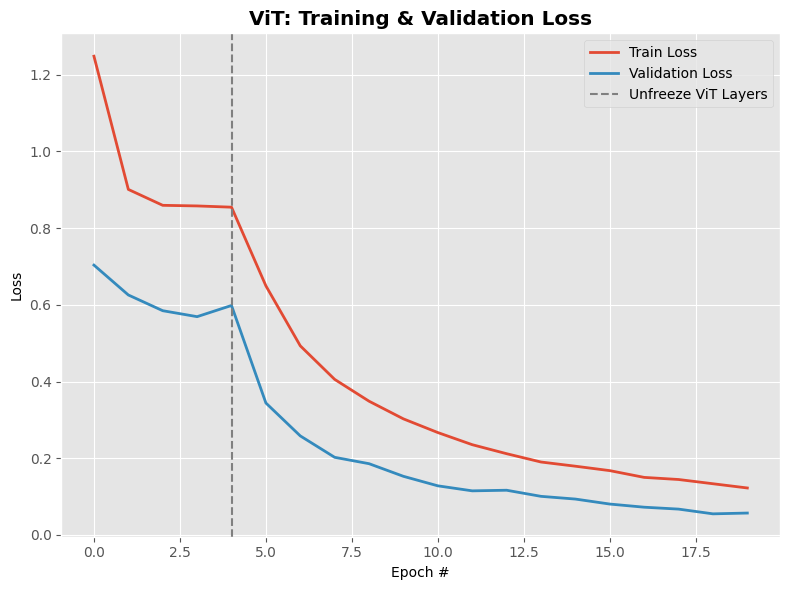

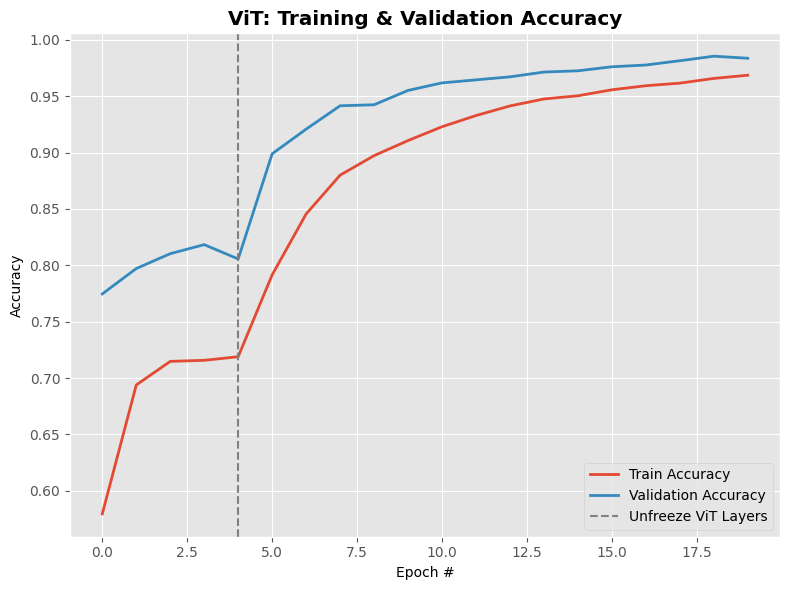

In [62]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc file history của ViT
with open('train_history.pkl', 'rb') as f:
    vit_history = pickle.load(f)

# 2. Gộp dữ liệu của Phase 1 (Warm-up) và Phase 2 (Fine-tuning)
loss = vit_history['phase1']['loss'] + vit_history['phase2']['loss']
val_loss = vit_history['phase1']['val_loss'] + vit_history['phase2']['val_loss']

acc = vit_history['phase1']['accuracy'] + vit_history['phase2']['accuracy']
val_acc = vit_history['phase1']['val_accuracy'] + vit_history['phase2']['val_accuracy']

# Điểm giao thời giữa 2 phase (Ví dụ: sau epoch 5)
unfreeze_epoch = len(vit_history['phase1']['loss'])

plt.style.use("ggplot")

# ==========================================
# ẢNH 1: BIỂU ĐỒ LOSS (HÀM MẤT MÁT)
# ==========================================
plt.figure(figsize=(8, 6))
plt.plot(loss, label="Train Loss", linewidth=2)
plt.plot(val_loss, label="Validation Loss", linewidth=2)
# Vẽ đường vạch đích thể hiện lúc mở khóa (Unfreeze)
plt.axvline(x=unfreeze_epoch - 1, color='gray', linestyle='--', label='Unfreeze ViT Layers')

plt.title("ViT: Training & Validation Loss", fontweight='bold')
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

# Mở comment dòng dưới nếu bạn muốn lưu trực tiếp thành file ảnh
# plt.savefig("vit_loss.png", dpi=300) 
plt.show()


# ==========================================
# ẢNH 2: BIỂU ĐỒ ACCURACY (ĐỘ CHÍNH XÁC)
# ==========================================
plt.figure(figsize=(8, 6))
plt.plot(acc, label="Train Accuracy", linewidth=2)
plt.plot(val_acc, label="Validation Accuracy", linewidth=2)
# Vẽ đường vạch đích thể hiện lúc mở khóa (Unfreeze)
plt.axvline(x=unfreeze_epoch - 1, color='gray', linestyle='--', label='Unfreeze ViT Layers')

plt.title("ViT: Training & Validation Accuracy", fontweight='bold')
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend(loc="lower right") # Chuyển ghi chú xuống góc phải cho đỡ che đồ thị
plt.tight_layout()

# Mở comment dòng dưới nếu bạn muốn lưu trực tiếp thành file ảnh
# plt.savefig("vit_accuracy.png", dpi=300) 
plt.show()

# 	Prediction and Inference

In [1]:
import tensorflow as tf
from vit_keras import vit

vit_base = vit.vit_b16(
image_size=224, activation='softmax', pretrained=True, 
include_top=False, pretrained_top=False
)
vit_base.trainable = False

model = tf.keras.Sequential([
    vit_base,
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(10, activation='softmax')
    ])

vit_base.trainable = True
for layer in vit_base.layers[:-4]:
    layer.trainable = False

c:\Users\slywi\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\slywi\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If 

In [2]:
import cv2
class SimplePreprocessor:
	def __init__(self, width, height, inter=cv2.INTER_AREA):
		# store the target image width, height, and interpolation
		# method used when resizing
		self.width = width
		self.height = height
		self.inter = inter

	def preprocess(self, image):
		# resize the image to a fixed size, ignoring the aspect
		# ratio
		return cv2.resize(image, (self.width, self.height),
			interpolation=self.inter)

In [3]:
# initialize the image preprocessors
sp = SimplePreprocessor(128,128)

for getting output from trained modle you need give model file and random input image where you can get from Alzheimer_Classification folder

In [4]:
# Load the weights
model.load_weights('vit_distraction_weights.weights.h5')
print("Model weights loaded successfully!")

Model weights loaded successfully!


1/1 [==============================] - 9s 9s/step


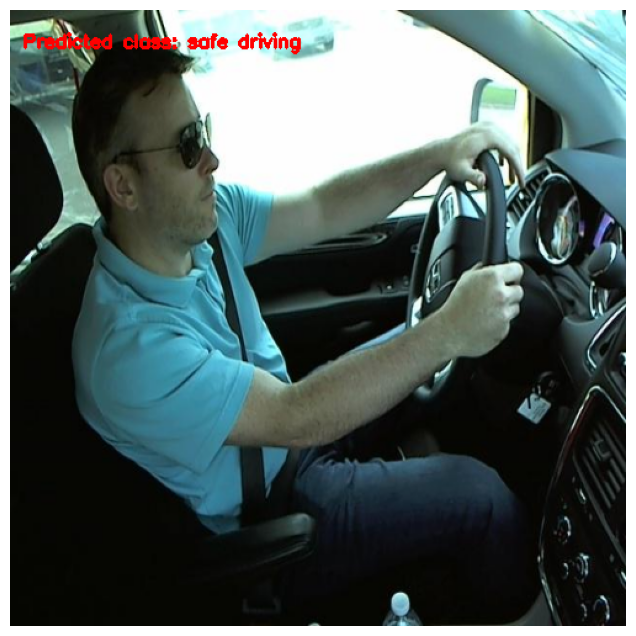

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from vit_keras import vit

# 1. Tải ảnh
image_path = "Driver_Distraction_Detection/imgs/test/img_22.jpg"
#image_path = "11.png"
image = cv2.imread(image_path)

# [QUAN TRỌNG] Chuyển đổi hệ màu từ BGR của OpenCV sang RGB chuẩn của mô hình
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Tiền xử lý dữ liệu chuẩn cho ViT
# Thay thế SimplePreprocessor và dòng chia 255.0 bằng hàm của ViT
img_resized = cv2.resize(image_rgb, (224, 224))
data = vit.preprocess_inputs(img_resized)
data = np.expand_dims(data, axis=0) # Thêm chiều batch, shape: (1, 224, 224, 3)

# 3. Dự đoán bằng mô hình
prediction = model.predict(data)
Name = [
    "safe driving",
    "texting - right",
    "talking on the phone - right",
    "texting - left",
    "talking on the phone - left",
    "operating the radio",
    "drinking",
    "reaching behind",
    "hair and makeup",
    "talking to passenger"
]
predicted_class = Name[prediction.argmax()]

# 4. Viết chữ lên ảnh để hiển thị
# Resize ảnh lớn hơn một chút để dễ nhìn bằng mắt thường
display_img = cv2.resize(image_rgb, (500, 500))

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
font_thickness = 2
text_color = (255, 0, 0)  # Màu Đỏ trong hệ RGB (R=255, G=0, B=0)
text = f"Predicted class: {predicted_class}"

# Chèn text vào góc trên (x=10, y=30)
cv2.putText(display_img, text, (10, 30), font, font_scale, text_color, font_thickness)

# 5. Hiển thị ảnh ngay trong Jupyter Notebook
plt.figure(figsize=(8, 8))
plt.imshow(display_img)
plt.axis('off') # Ẩn các trục tọa độ
plt.show()